# Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
game_level_features = pd.read_parquet("data/aggregated/game_level_features_22_25.parquet")
game_level_features["game_date"] = pd.to_datetime(game_level_features["game_date"], errors="coerce")
game_level_features.head(10)

,game_id,game_date,home_team,away_team,starter_pitcher_name_home,starter_pitcher_name_away,Δstarter_FIP_3G,Δstarter_WHIP_3G,Δstarter_K9_3G,Δstarter_HR9_3G,...,Δroll_3G_ISO,Δroll_7G_OBP,Δroll_7G_ISO,ΔBIP_out_rate_3G,ΔBIP_out_rate_7G,home_win,run_diff,Δwin_pct_7G,Δwin_pct_10G,ballpark
0,661042,2022-04-07,LAA,HOU,"Ohtani, Shohei","Valdez, Framber",-0.501346,-0.173269,2.362500,0.228462,...,-0.013193,-0.027160,-0.013193,-0.030054,-0.030054,0,-2,-0.111111,-0.111111,LAA
1,661577,2022-04-07,ATL,CIN,"Fried, Max","Mahle, Tyler",-0.500258,-0.156226,-1.896095,-0.385842,...,0.006274,-0.011229,0.006274,0.016629,0.016629,0,-3,0.034238,0.034238,ATL
2,662021,2022-04-07,STL,PIT,"Wainwright, Adam","Brubaker, JT",-1.496179,-0.272351,-1.838997,-1.136493,...,0.038504,0.004731,0.038504,0.028652,0.028652,1,9,0.179012,0.179012,STL
3,662571,2022-04-07,WSH,NYM,"Corbin, Patrick","Megill, Tylor",0.740873,0.193245,-2.388419,0.048493,...,0.008000,0.021413,0.008000,-0.004304,-0.004304,0,-4,-0.074074,-0.074074,WSH
4,662766,2022-04-07,KC,CLE,"Greinke, Zack","Bieber, Shane",1.678132,-0.063212,-6.238713,0.528978,...,-0.019450,0.005893,-0.019450,-0.019316,-0.019316,1,2,-0.037037,-0.037037,KC
5,663178,2022-04-07,CHC,MIL,"Hendricks, Kyle","Burnes, Corbin",3.291359,0.458473,-6.062442,1.182810,...,0.007685,-0.005448,0.007685,-0.019441,-0.019441,1,1,-0.148148,-0.148148,CHC
6,663418,2022-04-07,AZ,SD,"Bumgarner, Madison","Darvish, Yu",0.751171,0.133199,-3.039157,-0.018072,...,-0.012834,-0.011187,-0.012834,-0.013363,-0.013363,1,2,-0.166667,-0.166667,AZ
7,661041,2022-04-08,LAA,HOU,"Detmers, Reid","Odorizzi, Jake",1.796577,0.580195,0.382809,0.753655,...,-0.216749,-0.095925,-0.216749,-0.079051,-0.079051,0,-7,-1.000000,-1.000000,LAA
8,661131,2022-04-08,PHI,ATH,"Nola, Aaron","Montas, Frankie",-0.005405,-0.049099,1.079730,0.327027,...,-0.001215,-0.000515,-0.001215,-0.004885,-0.004885,1,4,-0.024691,-0.024691,PHI
9,661333,2022-04-08,NYY,BOS,"Cole, Gerrit","Eovaldi, Nathan",0.132353,-0.165441,2.382353,0.446691,...,-0.016365,-0.005154,-0.016365,0.034455,0.034455,1,1,0.000000,0.000000,NYY


## Structural Examination

### Shape

In [3]:
game_level_features.shape

(9719, 33)

### Unique ID's

In [4]:
game_level_features["game_id"].is_unique

True

### Win Balance Outcome

In [5]:
game_level_features["home_win"].value_counts(normalize=True)

home_win
1    0.529581
0    0.470419
Name: proportion, dtype: float64

## Pitching Analysis 

### Starting Pitcher Distribution

In [6]:
game_level_features.filter(like="Δstarter").describe()

,Δstarter_FIP_3G,Δstarter_WHIP_3G,Δstarter_K9_3G,Δstarter_HR9_3G,Δstarter_FIP_7G,Δstarter_WHIP_7G,Δstarter_K9_7G,Δstarter_HR9_7G
count,9719.000000,9.719000e+03,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000
mean,0.017502,9.257598e-03,-0.013511,-0.003982,0.025266,0.008290,-0.017261,0.003231
std,2.792398,7.483961e-01,3.709555,1.585772,2.418433,0.663575,3.233184,1.354392
min,-62.750000,-2.294118e+01,-21.288462,-26.470588,-62.750000,-22.941176,-20.647059,-26.470588
25%,-1.472975,-3.573455e-01,-2.376179,-0.857143,-1.163762,-0.278768,-1.985711,-0.642367
50%,0.000000,2.220446e-16,0.000000,0.000000,0.015345,0.006435,0.000000,0.000000
75%,1.507484,3.750981e-01,2.376567,0.854376,1.218488,0.297676,1.981252,0.652020
max,35.666667,1.076786e+01,20.543478,21.000000,35.666667,10.956522,20.008929,21.000000


In [7]:
'''
Move to Script!
'''

def plot_delta_boxplots(
    df,
    like: str,
    title: str | None = None,
    feature_col: str = "Feature",
    value_col: str = "Value",
    figsize: tuple[int, int] = (12, 5),
    rotate_xticks: int = 90,
    dropna: bool = True,
) -> None:
    """
    Boxplot distributions for a set of columns selected via df.filter(like=...).

    Intended for quick EDA of delta features (e.g., Δstarter, Δbullpen).
    """
    sub = df.filter(like=like)
    if sub.shape[1] == 0:
        raise ValueError(f"No columns matched like='{like}'")

    long = sub.melt(var_name=feature_col, value_name=value_col)
    if dropna:
        long = long.dropna()

    plt.figure(figsize=figsize)
    sns.boxplot(data=long, x=feature_col, y=value_col)
    plt.xticks(rotation=rotate_xticks)
    plt.title(title or f"Boxplot Distribution for columns like '{like}'")
    plt.tight_layout()
    plt.show()

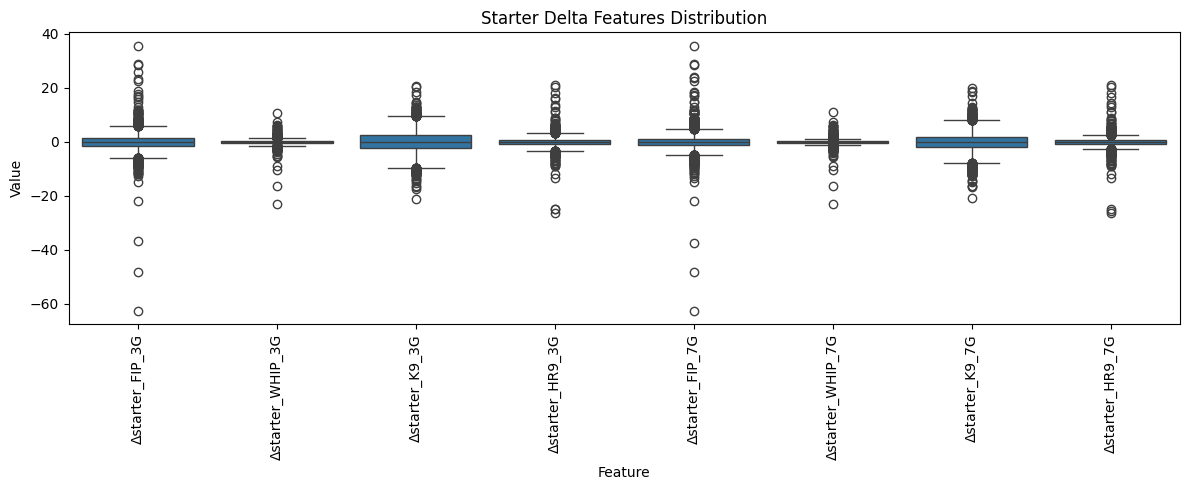

In [8]:
plot_delta_boxplots(game_level_features, like="Δstarter", title="Starter Delta Features Distribution")

#### Analysis

The distributions of the pitching delta features are generally centered around zero, with both the means and medians very close to zero. This is expected since the variables represent the difference between the home and away teams' metrics for a given game.

Overall, the distributions appear roughly symmetric around zero. Both the means and medians of the pitching delta features are very close to zero across all metrics, and the first and third quartiles are also fairly balanced around zero. This suggests that positive and negative pitching differences occur at similar rates across games.

As expected, the 3-game rolling windows (3G) show a wider spread compared to the 7-game rolling windows (7G). This makes sense because shorter rolling windows are more sensitive to recent performance and therefore tend to be noisier, while longer windows smooth out variability over a larger sample of games.

The number and magnitude of outliers appear relatively similar between the 3G and 7G windows, indicating that extreme differences between teams can occur regardless of the smoothing window.

Among the metrics, starter FIP exhibits the most extreme outliers, with some values reaching roughly −60 to +35. This likely reflects situations where there is a large difference in the recent performance of the two starting pitchers.

### Distribution by Win

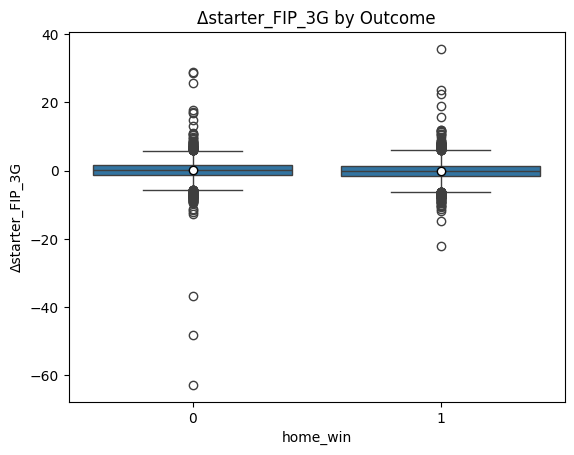

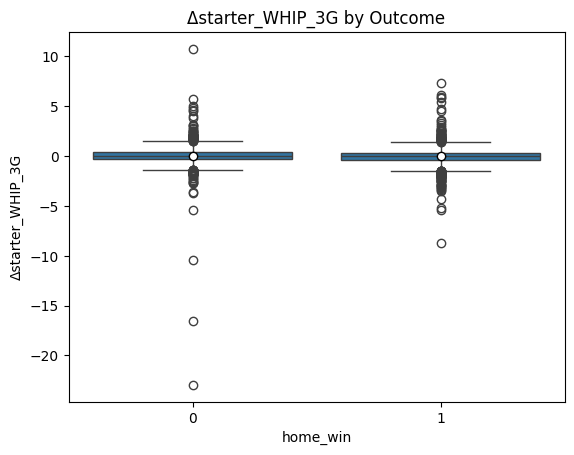

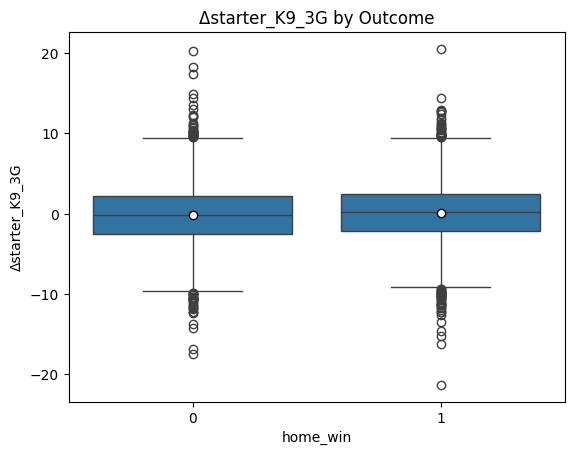

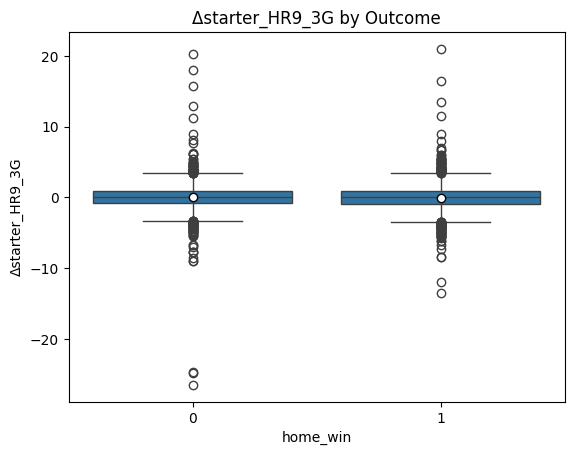

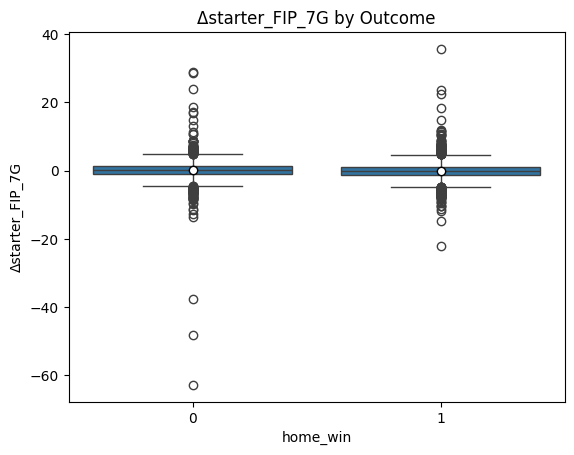

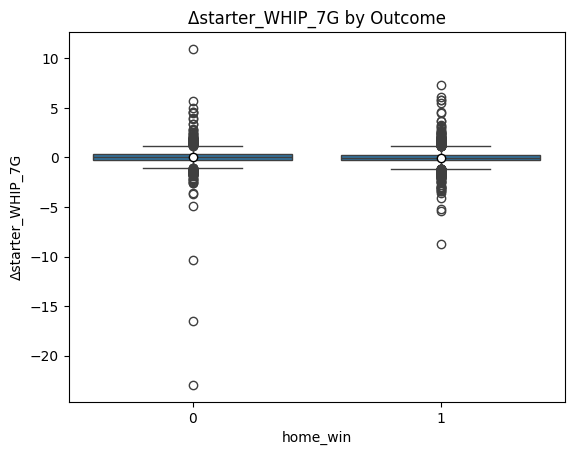

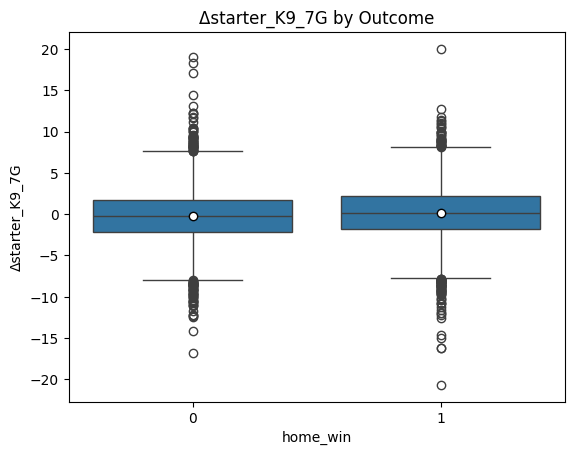

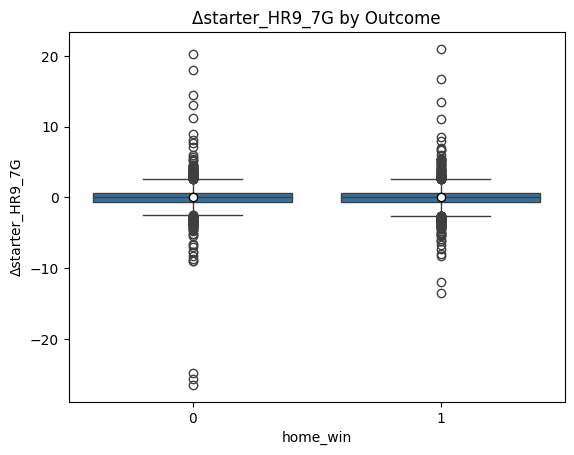

In [45]:
delta_starter = game_level_features.filter(like="Δstarter_")

for col in delta_starter.columns:
    plt.figure()
    sns.boxplot(
        data=game_level_features,
        x="home_win",
        y=col,
        showmeans=True,
        meanprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 6
        }
    )
    
    plt.title(f"{col} by Outcome")
    plt.show()

#### Starter Pitching Delta Features by Game Outcome

# TODO: ADD ANALYSIS OF MEAN!

Across all starter delta features (FIP, WHIP, K9, and HR9) for both the 3-game and 7-game rolling windows, the distributions are centered very close to zero for both home wins and losses. This indicates that in many games the recent performance of the home and away starting pitchers is relatively similar. The interquartile ranges and overall spreads of the distributions are also largely overlapping between outcomes, suggesting that no single starter metric alone strongly separates wins from losses. However, slight directional tendencies are visible: negative values of metrics where lower is better (such as $\Delta FIP$ and $\Delta WHIP$) and positive values where higher is better (such as $\Delta K9$) appear somewhat more common in the home win group. Overall, this suggests that starter matchup differences may contribute modest predictive signal, but are unlikely to fully explain game outcomes without considering other components such as bullpen performance and offensive strength.

###  Density Plots by Outcome

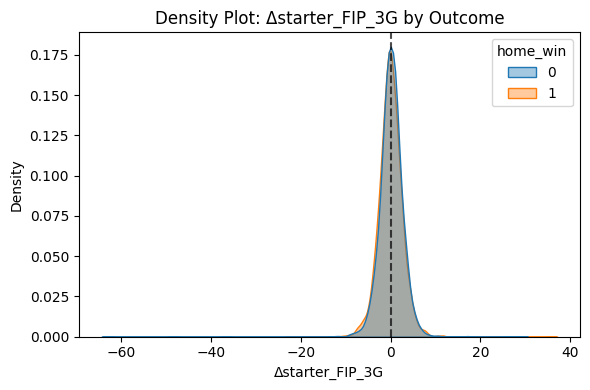

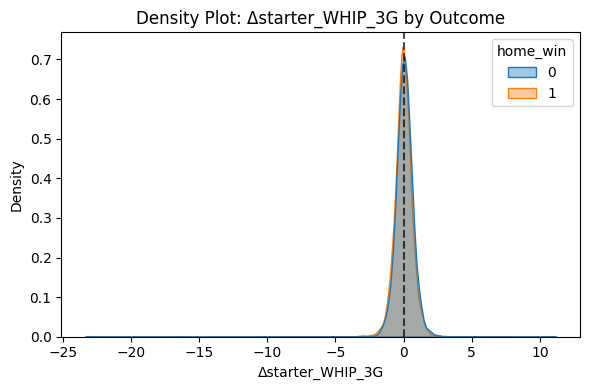

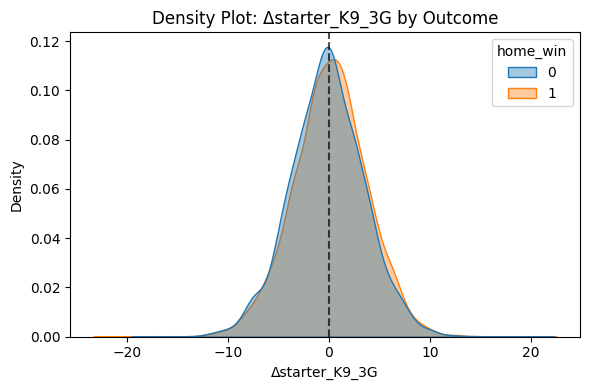

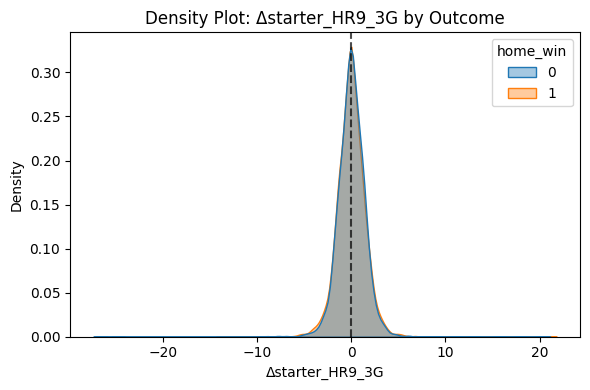

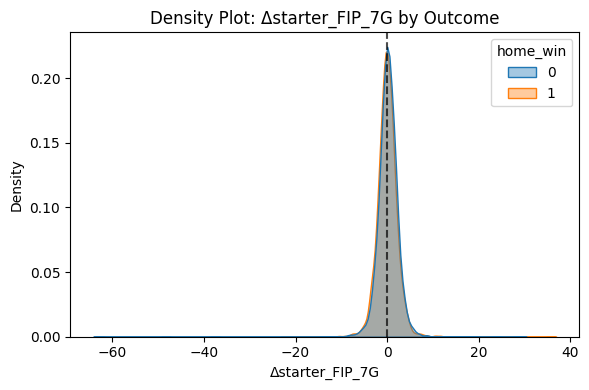

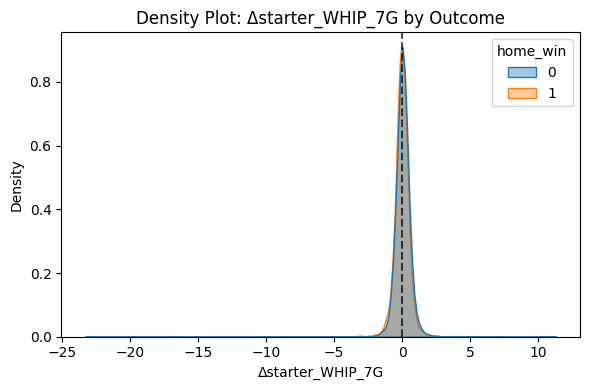

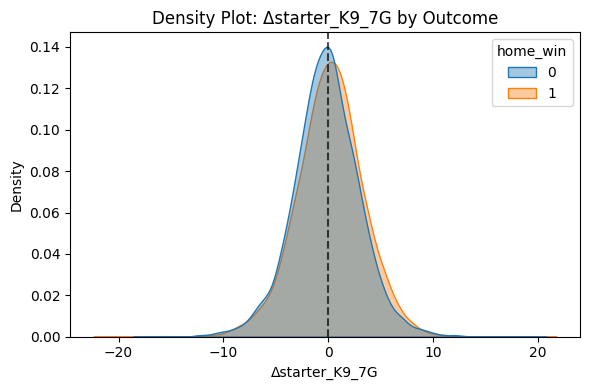

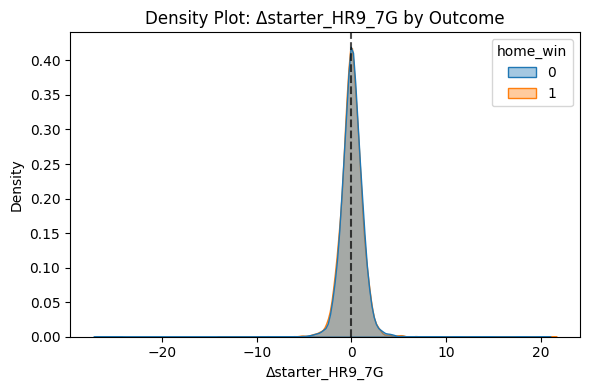

In [47]:
starter_cols = game_level_features.filter(like="Δstarter_").columns

for col in starter_cols:
    plt.figure(figsize=(6,4))

    sns.kdeplot(
        data=game_level_features,
        x=col,
        hue="home_win",
        fill=True,
        common_norm=False,
        alpha=0.4
    )

    plt.axvline(0, linestyle="--", color="black", alpha=0.7)

    plt.title(f"Density Plot: {col} by Outcome")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

# TODO: ADD ANALYSIS!

### Bullpen Pitcher Distribution

In [10]:
game_level_features.filter(like="Δbullpen").describe()

,Δbullpen_FIP_3G,Δbullpen_WHIP_3G,Δbullpen_K9_3G,Δbullpen_HR9_3G,Δbullpen_FIP_7G,Δbullpen_WHIP_7G,Δbullpen_K9_7G,Δbullpen_HR9_7G
count,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000,9719.000000
mean,-0.099981,-0.027933,0.040103,-0.018575,0.019050,0.001935,0.035793,0.018601
std,2.559154,0.680857,3.615903,1.450991,1.738432,0.464508,2.526978,0.967504
min,-14.075051,-2.837143,-14.170807,-8.598377,-13.800000,-2.708333,-11.250000,-6.300000
25%,-1.700000,-0.465058,-2.319832,-0.900000,-1.063828,-0.302974,-1.637250,-0.584820
50%,-0.056250,-0.018634,0.072193,0.000000,0.017408,0.004412,0.046950,0.000000
75%,1.534149,0.421904,2.446719,0.843750,1.161917,0.306405,1.701640,0.622110
max,13.364764,3.583333,16.500000,7.838710,9.262987,3.583333,16.500000,6.750000


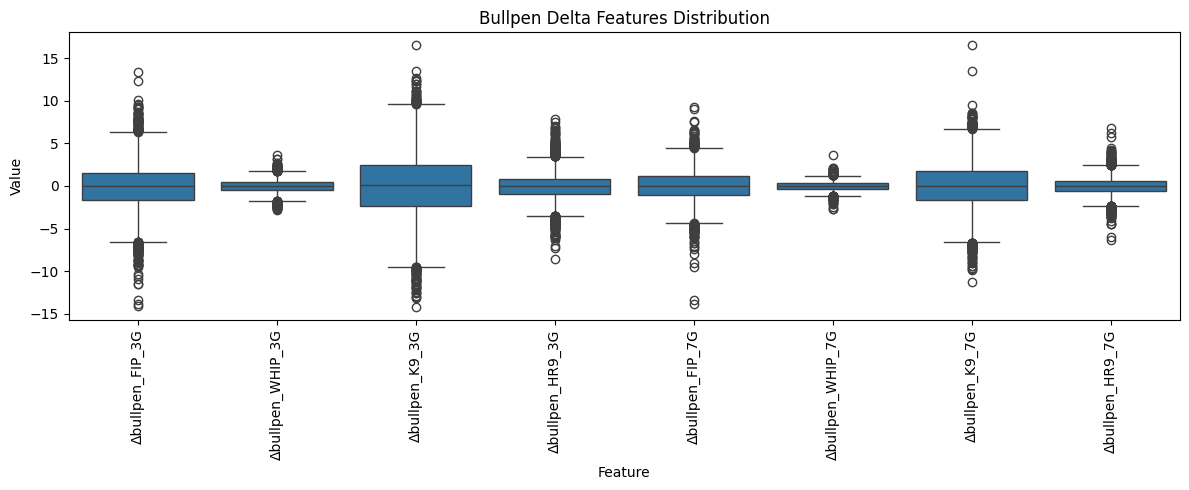

In [11]:
plot_delta_boxplots(game_level_features, like="bullpen", title="Bullpen Delta Features Distribution")

#### Analysis

The distributions of the bullpen delta features show patterns very similar to those observed for the starter delta features. Across all metrics, the distributions are centered close to zero, with both means and medians near zero, which is expected since these variables represent the difference between the home and away teams' bullpen performance.

As with the starter metrics, the 3-game rolling windows (3G) exhibit a wider spread than the 7-game windows (7G), reflecting the greater variability of shorter rolling samples. The overall shapes of the distributions are also fairly symmetric around zero.

One noticeable difference is that the bullpen features tend to exhibit slightly larger interquartile ranges than the starter features, indicating somewhat greater variability in recent bullpen performance between teams. Additionally, the bullpen features show fewer extreme values overall, particularly compared to the large outliers observed in starter FIP.

### Bullpen Delta Features by Game Outcome


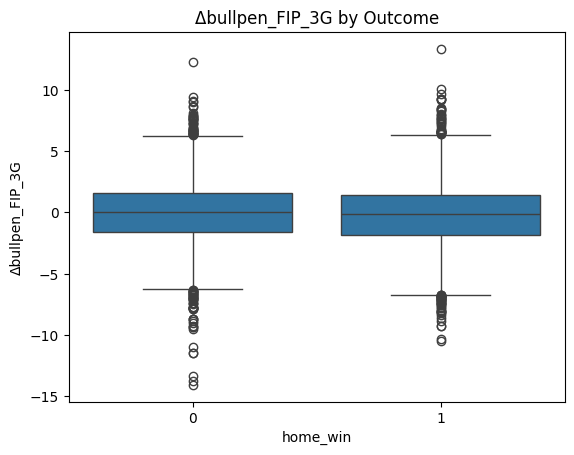

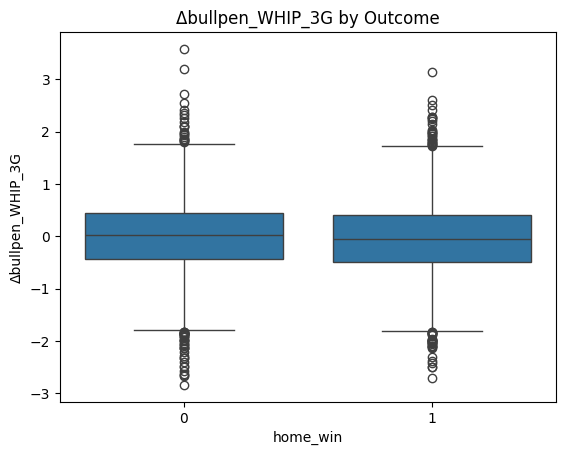

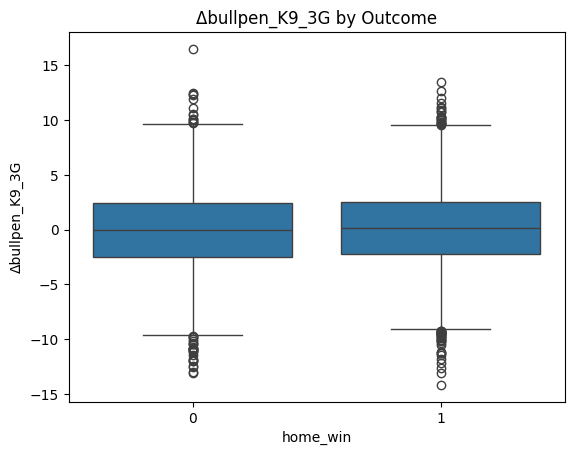

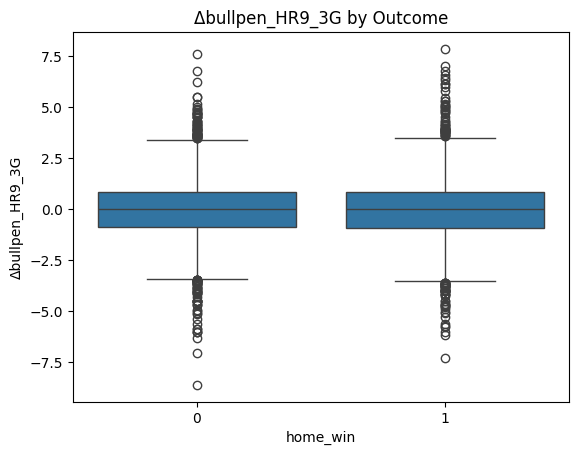

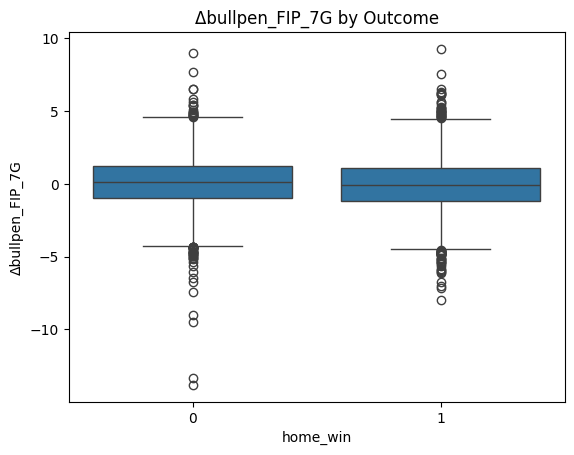

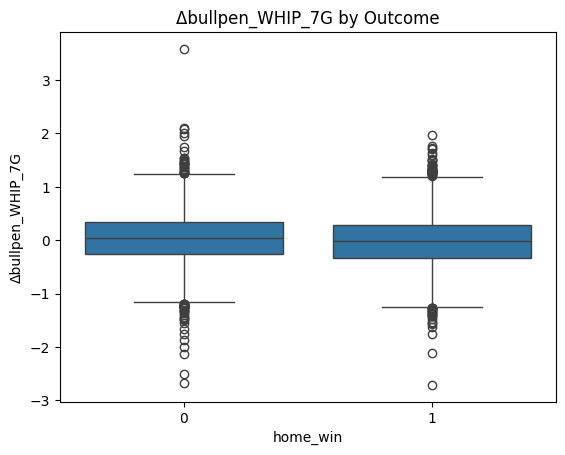

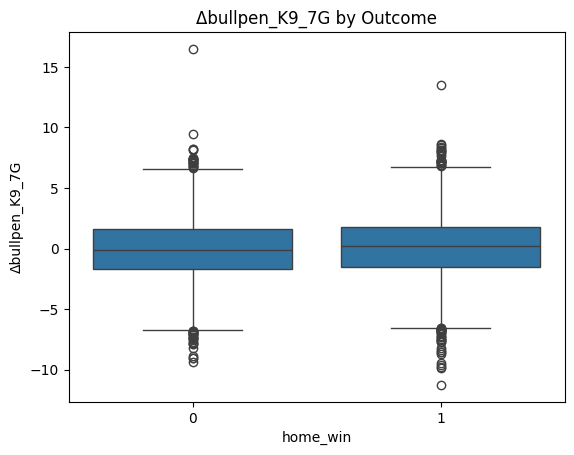

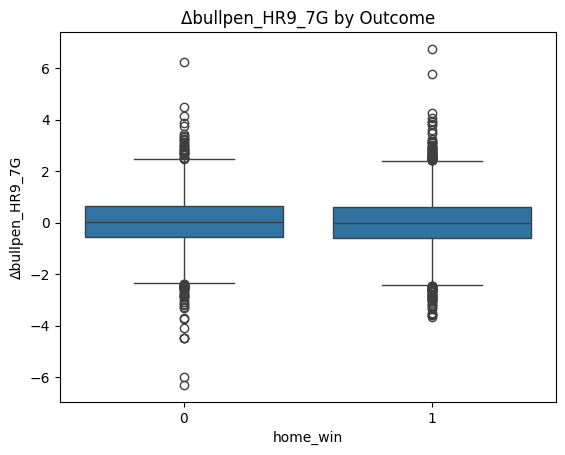

In [12]:
delta_bullpen = game_level_features.filter(like="Δbullpen_")

for col in delta_bullpen.columns:
    plt.figure()
    sns.boxplot(
        data=game_level_features,
        x="home_win",
        y=col
    )
    plt.title(f"{col} by Outcome")
    plt.show()

#### Analysis

Across all bullpen delta features (FIP, WHIP, K9, and HR9) for both the 3-game and 7-game rolling windows, the distributions for home wins and losses overlap substantially. The medians for both outcomes are generally close to zero, indicating that the recent bullpen performance of the two teams is often fairly similar entering a game. As a result, no single bullpen metric clearly separates wins from losses on its own.

However, slight directional tendencies can still be observed. When the home team wins, values of metrics where lower is better (such as $\Delta FIP$ and $\Delta WHIP$) tend to be slightly more negative, while metrics where higher is better (such as $\Delta K9$) tend to be slightly more positive. This suggests that better recent bullpen performance relative to the opponent may contribute modest predictive signal.

Overall, these patterns closely mirror those observed in the starter delta features: pitching advantages appear to matter, but the substantial overlap between the win and loss distributions indicates that bullpen differences alone are unlikely to determine game outcomes without considering other factors such as starting pitching and offensive performance.

### Pitching Correlation Analysis

In [27]:
def plot_delta_corr_heatmap(
    df: pd.DataFrame,
    group: str = "pitching",  # "pitching", "batting", "fielding", "winning", "all"
    prefix: str = "Δ",
    group_map: dict[str, tuple[str, ...]] | None = None,
    figsize: tuple[int, int] = (12, 10),
    title: str | None = None,
    fmt: str = ".2f",
    annot_fontsize: int = 8,
) -> None:
    """
    Plot a lower-triangle correlation heatmap for delta features.

    Default group_map:
      pitching -> ("Δstarter_", "Δbullpen_")
      batting  -> ("Δroll_",)
      fielding -> ("ΔBIP_",)
      winning  -> ("Δwin_pct_",)
      all      -> all columns starting with "Δ"

    Returns None (plots only).
    """

    default_group_map = {
        "pitching": (f"{prefix}starter_", f"{prefix}bullpen_"),
        "batting":  (f"{prefix}roll_",),
        "fielding": (f"{prefix}BIP_",),
        "winning":  (f"{prefix}win_pct_",),
        "all":      (prefix,),
    }
    group_map = default_group_map if group_map is None else group_map

    if group not in group_map:
        raise ValueError(f"group must be one of {list(group_map.keys())}. Got: {group}")

    tokens = group_map[group]

    # Select columns
    if group == "all":
        cols = [c for c in df.columns if isinstance(c, str) and c.startswith(prefix)]
    else:
        cols = [c for c in df.columns if isinstance(c, str) and any(c.startswith(t) for t in tokens)]

    if len(cols) < 2:
        raise ValueError(f"Not enough columns found for group='{group}'. Found {len(cols)}.")

    # Sort: 3G before 7G before 10G (if present)
    def _win_rank(c: str) -> int:
        cu = c.upper()
        if cu.endswith("_3G"):
            return 0
        if cu.endswith("_7G"):
            return 1
        if cu.endswith("_10G"):
            return 2
        return 3

    cols = sorted(cols, key=lambda c: (_win_rank(c), c))

    corr = df[cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle incl diagonal

    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        corr,
        mask=mask,
        cmap="coolwarm",
        center=0,
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        annot=True,
        fmt=fmt,
        annot_kws={"size": annot_fontsize},
    )

    if title is None:
        title = f"Correlation Heatmap: {group.capitalize()} Delta Features"
    ax.set_title(title)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

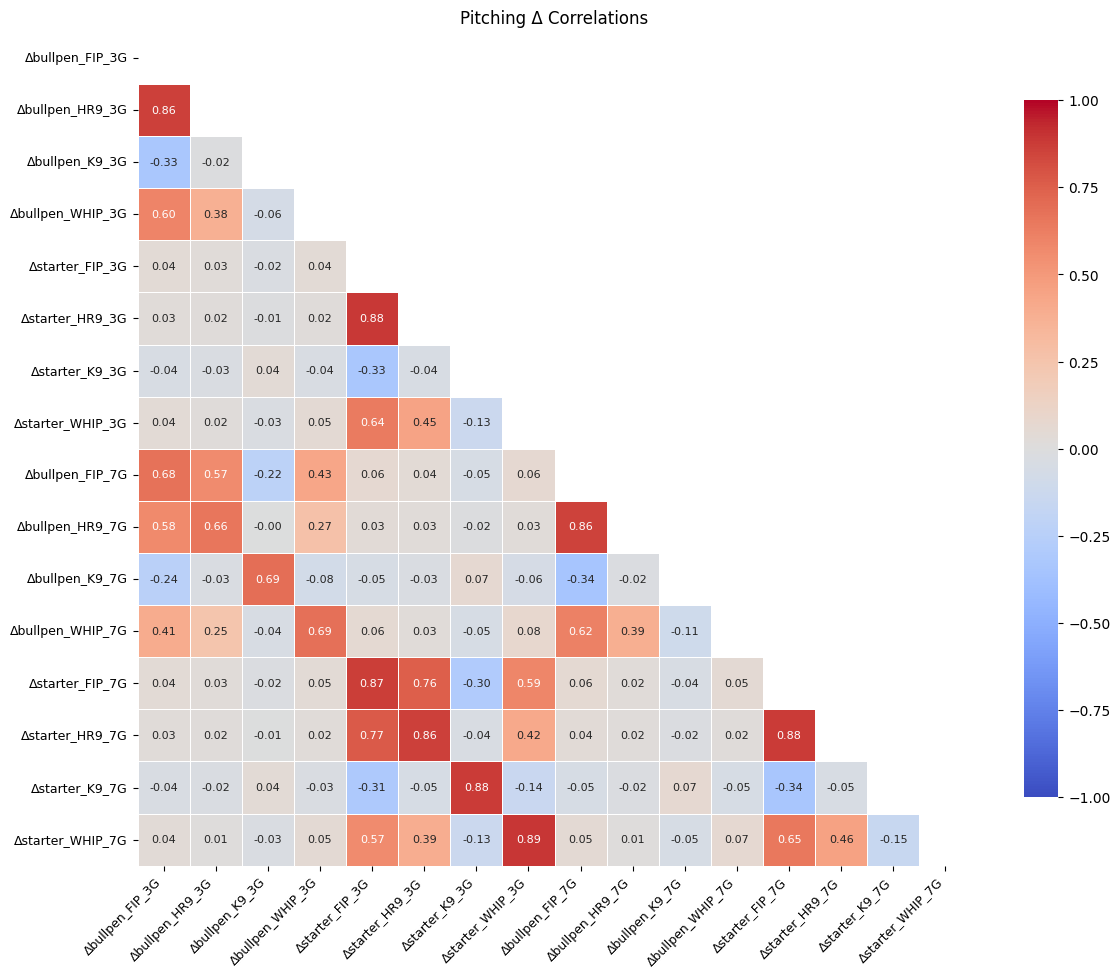

In [28]:
plot_delta_corr_heatmap(game_level_features, group="pitching", title="Pitching Δ Correlations")

#### Pitcher Heatmap Analysis 
| Feature 1          | Feature 2          | Correlation |
|--------------------|--------------------|-------------|
| `Δstarter_WHIP_3G` | `Δstarter_WHIP_7G` | **0.89**    |
| `Δstarter_FIP_3G`  | `Δstarter_HR9_3G`  | **0.88**    |
| `Δstarter_K9_3G`   | `Δstarter_K9_7G`   | **0.88**    |
| `Δstarter_FIP_7G`  | `Δstarter_HR9_7G`  | **0.88**    |
| `Δbullpen_FIP_3G`  | `Δbullpen_HR9_3G`  | **0.86**    |
| `Δbullpen_FIP_7G`  | `Δbullpen_HR9_7G`  | **0.86**    |
| `Δstarter_HR9_3G`  | `Δstarter_HR9_7G`  | **0.86**    |

Two major patterns emerge from the correlation analysis. The first is that **FIP and HR9 are highly correlated**. For example, several pairs such as `Δstarter_FIP_3G` and `Δstarter_HR9_3G` have correlations well above 0.8. This is expected because HR9 is a direct component of FIP, meaning that differences in HR9 between teams strongly influence differences in FIP.

Second, **the 3G and 7G versions of the same metric are strongly correlated**. This pattern appears across both starter and bullpen metrics. This is expected because both rolling windows measure the same underlying skill, with the 7-game window simply providing a smoother estimate of recent performance. To address this during modeling, the **3G and 7G pitching features will be modeled separately**, preventing multicollinearity between different window lengths of the same statistic.

**Additional Notes**

It is also important to note that, while not exceeding the 0.8 threshold, several pairs still exhibit relatively strong correlations. For example, `Δstarter_FIP_7G` and `Δstarter_HR9_3G` have a correlation of 0.76. This further reflects the underlying relationship between HR9 and FIP, as home runs are a direct component of the FIP calculation. As a result, differences in HR9 between teams can still influence FIP even when measured across slightly different rolling windows.

## Batting Analysis 

### Batter Distributions

In [29]:
game_level_features.filter(like="Δroll").describe()

,Δroll_3G_OBP,Δroll_3G_ISO,Δroll_7G_OBP,Δroll_7G_ISO
count,9719.000000,9719.000000,9719.000000,9719.000000
mean,0.002625,0.002724,-0.000730,-0.000734
std,0.071909,0.090902,0.050625,0.063383
min,-0.250262,-0.380037,-0.243472,-0.380037
25%,-0.046633,-0.056196,-0.034227,-0.041283
50%,0.002732,0.000690,-0.000728,-0.000203
75%,0.051464,0.062326,0.032433,0.041508
max,0.287214,0.404856,0.287214,0.404856


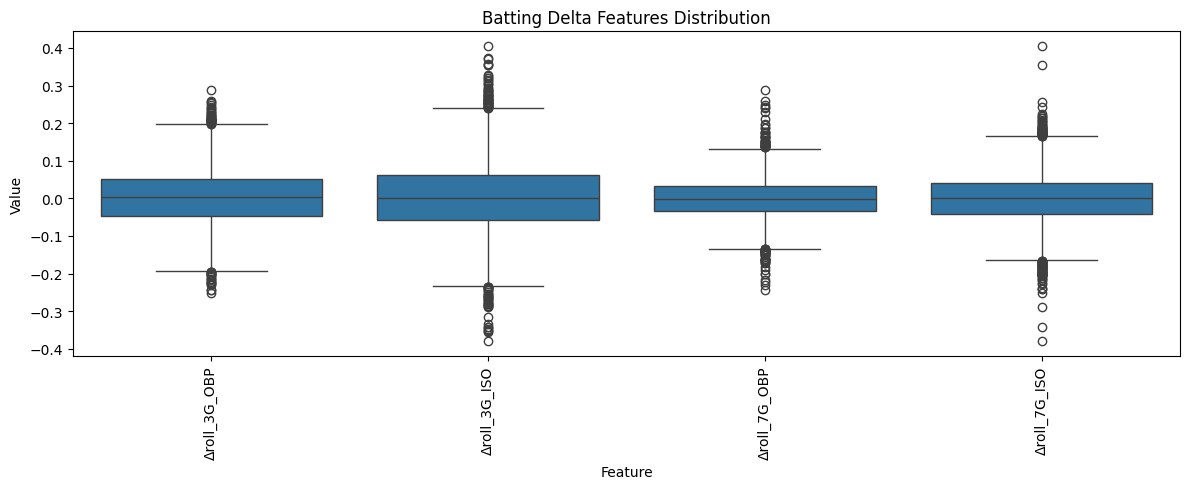

In [30]:
plot_delta_boxplots(game_level_features, like="roll", title="Batting Delta Features Distribution")

#### Analysis

The batting delta features (OBP and ISO) are centered very close to zero across both rolling windows, with means and medians near zero. This is expected since these variables represent the difference between the home and away teams’ recent batting performance entering a game.

Overall, the distributions appear roughly symmetric around zero. The first and third quartiles are fairly balanced around zero for both OBP and ISO, suggesting that positive and negative batting advantages occur at similar rates across games.

As expected, the 3-game rolling windows (3G) show a wider spread than the 7-game rolling windows (7G), reflecting the greater volatility of shorter samples. This is visible in the larger standard deviations for 3G compared to 7G for both OBP and ISO.

Finally, while outliers exist for both windows, they are relatively bounded compared to the pitching metrics, which is consistent with OBP and ISO being rate-based statistics that typically vary within a narrower range.

### Batting Delta Features by Game Outcome


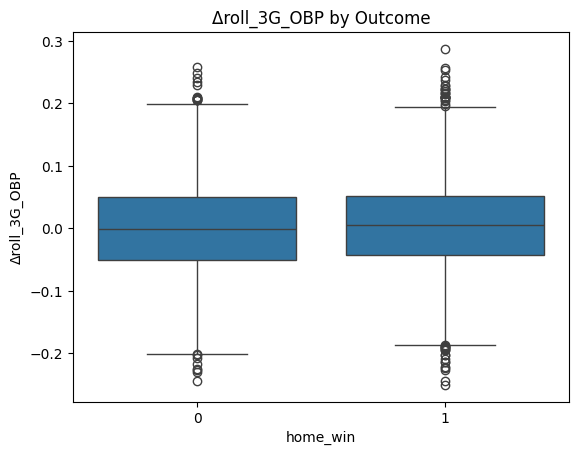

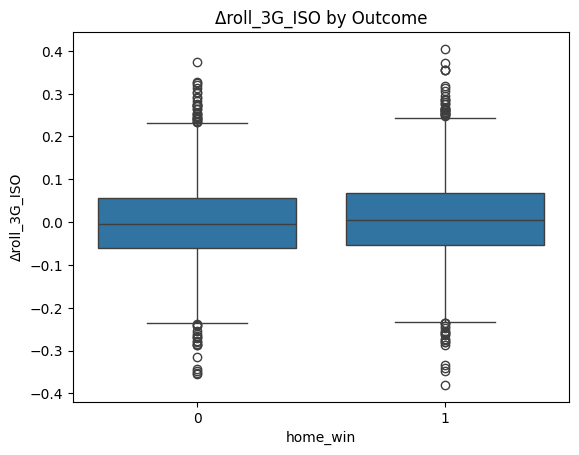

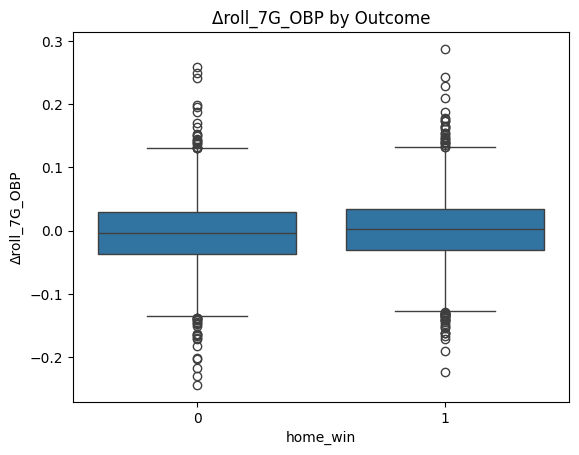

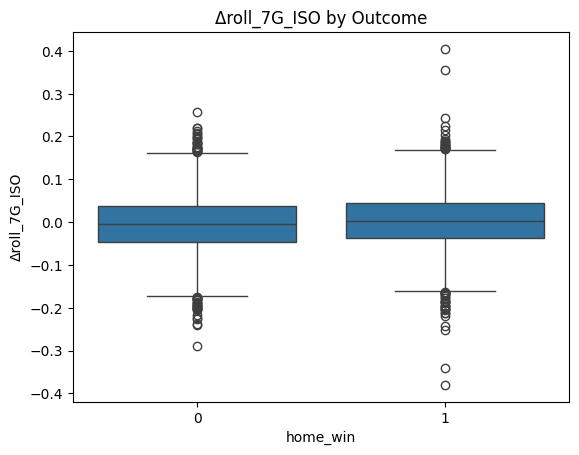

In [31]:
delta_batting = game_level_features.filter(like="Δroll_")

for col in delta_batting.columns:
    plt.figure()
    sns.boxplot(
        data=game_level_features,
        x="home_win",
        y=col
    )
    plt.title(f"{col} by Outcome")
    plt.show()

#### Analysis 

Across all four batting delta features (OBP and ISO for both the 3-game and 7-game rolling windows), the distributions for wins and losses show substantial overlap, indicating that recent offensive differences alone do not strongly separate game outcomes. However, a consistent directional pattern can still be observed across the plots.

Because the batting delta features are defined as the difference between the home and away teams' recent performance, positive values indicate that the home team has been performing better offensively entering the game, while negative values indicate an advantage for the away team. In the plots, games where the home team wins tend to exhibit slightly more positive values, while games where the home team loses tend to show values closer to zero or slightly negative.

This pattern appears consistently across both OBP and ISO metrics and across both rolling windows. The 7-game windows show somewhat tighter distributions than the 3-game windows, reflecting the smoothing effect of the longer sample. Overall, the results suggest that relative offensive performance provides a modest but consistent signal in predicting game outcomes.

### Batting Correlation Analysis

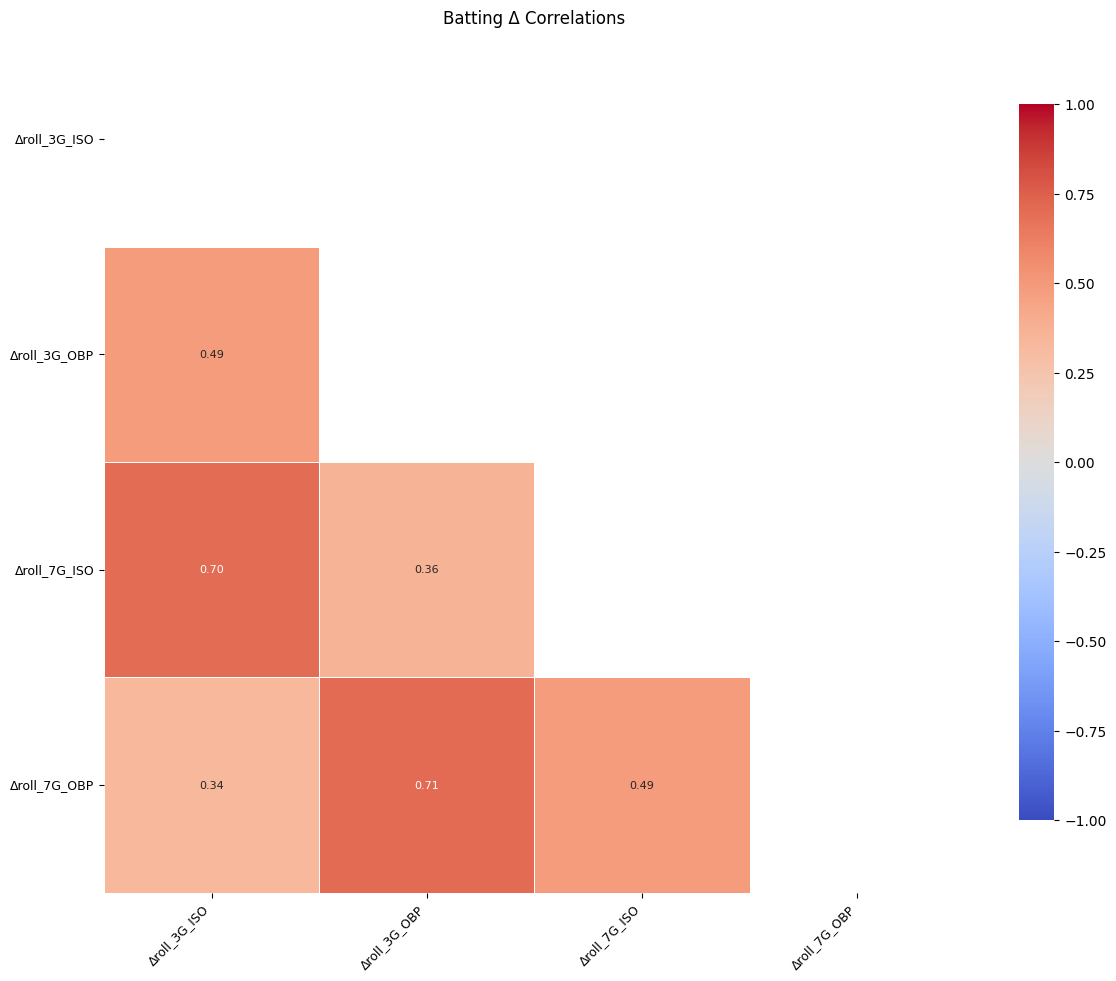

In [32]:
plot_delta_corr_heatmap(game_level_features, group="batting", title="Batting Δ Correlations")

#### Analysis


The batting delta features show moderate correlations but no extremely high multicollinearity. The strongest relationships occur between the **3-game and 7-game versions of the same metric**, with correlations of **0.70 for ISO** and **0.71 for OBP**. This is expected since both rolling windows capture the same underlying team hitting performance, but with different smoothing levels.

Correlations between **OBP and ISO** are lower, generally ranging between **0.34 and 0.49**, indicating that while the metrics are related, they capture somewhat different aspects of offensive production. **OBP reflects a team’s ability to reach base**, whereas **ISO measures power and extra-base hitting**. Overall, the correlations are moderate and remain well below the levels observed in some of the pitching features, suggesting that multicollinearity among the batting variables is less of a concern for modeling.

## Fielding Analysis

In [33]:
game_level_features.filter(like="ΔBIP").describe()

,ΔBIP_out_rate_3G,ΔBIP_out_rate_7G
count,9719.000000,9719.000000
mean,-0.000405,-0.001498
std,0.081264,0.055946
min,-0.315279,-0.291667
25%,-0.055785,-0.039070
50%,-0.001321,-0.001471
75%,0.054440,0.035747
max,0.400000,0.400000


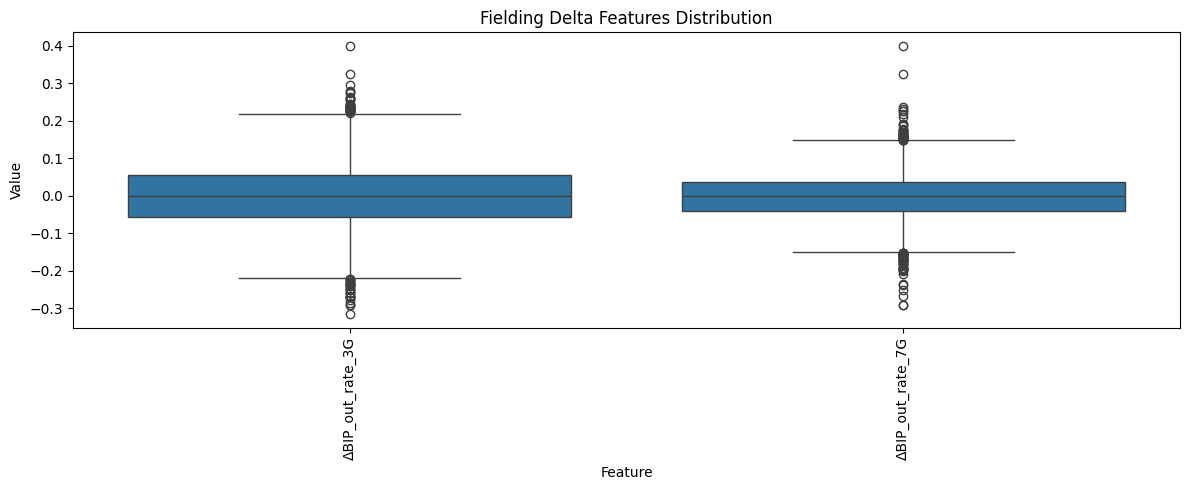

In [34]:
plot_delta_boxplots(game_level_features, like="ΔBIP", title="Fielding Delta Features Distribution")

#### Analysis

The winning percentage delta features are centered very close to zero, with both the mean and median values near zero for the 7-game and 10-game windows. This is expected because the variables represent the **difference in recent winning performance between the home and away teams**. Since each game involves two teams drawn from the same league, positive and negative differences naturally balance out over the full sample.

The distributions appear relatively symmetric around zero, indicating that games where the home team has recently performed better occur at roughly the same frequency as games where the away team has the stronger recent record. As with many rolling performance metrics, the 7-game window shows a wider spread than the 10-game window, reflected in the larger standard deviation and broader interquartile range. Shorter windows react more strongly to recent streaks or slumps, which increases variability.

The observed values range from −1.00 to +1.00, which corresponds to extreme cases where one team has recently won all of its games in the rolling window while the other has lost all of its games. These situations appear as outliers in the boxplots but are relatively rare. Most observations remain clustered near zero, suggesting that in most matchups the two teams have fairly similar recent performance, with large differences in recent winning percentage occurring only occasionally.

### Fielding Delta Features by Game Outcome


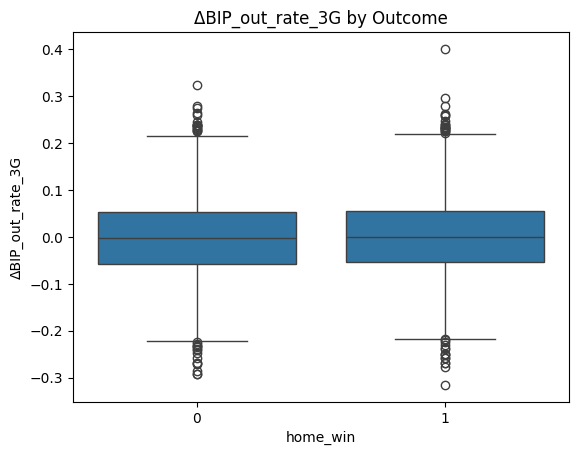

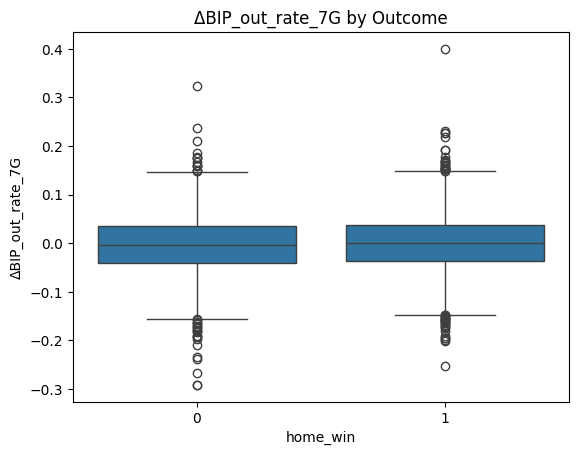

In [35]:
delta_fielding = game_level_features.filter(like="ΔBIP")

for col in delta_fielding.columns:
    plt.figure()
    sns.boxplot(
        data=game_level_features,
        x="home_win",
        y=col
    )
    plt.title(f"{col} by Outcome")
    plt.show()

#### Analysis

The distributions of the fielding delta features show a slight shift between wins and losses. In both the **3-game (3G)** and **7-game (7G)** windows, games where the home team wins tend to have slightly more positive values of **ΔBIP_out_rate**, while losses tend to be associated with more negative values. This suggests that when the home team has recently converted a higher proportion of balls in play into outs relative to the opposing team, they are somewhat more likely to win.

However, the overlap between the two distributions is still substantial, indicating that the signal is relatively modest. The medians for wins appear slightly higher than those for losses, but the interquartile ranges largely overlap. As with other rolling metrics, the **3-game window shows greater variability**, while the **7-game window appears more concentrated due to the smoothing effect of the longer rolling period**.

### Fielding Correlation

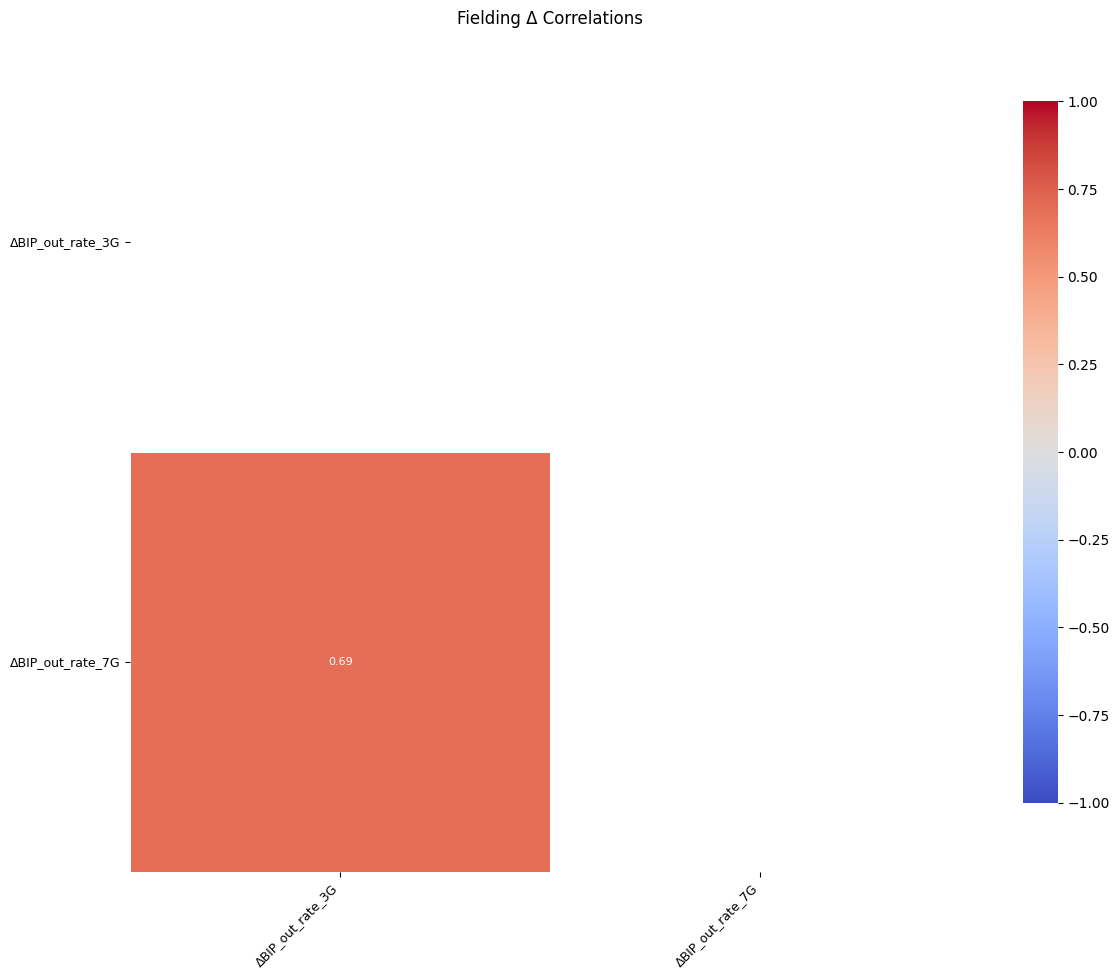

In [36]:
plot_delta_corr_heatmap(game_level_features, group="fielding", title="Fielding Δ Correlations")

#### Analysis

The fielding delta features show a **moderate correlation** between the 3-game and 7-game rolling windows, with a correlation of **0.69** between `ΔBIP_out_rate_3G` and `ΔBIP_out_rate_7G`. This relationship is expected since both variables measure the same underlying defensive metric—the rate at which balls in play are converted into outs—but over different rolling time horizons. Overall, the level of correlation does not appear high enough to raise strong concerns about multicollinearity, especially since the **3G and 7G versions will be modeled separately**.

## Past Win Analysis

In [37]:
game_level_features.filter(like="Δwin").describe()

,Δwin_pct_7G,Δwin_pct_10G
count,9719.000000,9719.000000
mean,-0.008681,-0.009277
std,0.326978,0.284258
min,-1.000000,-1.000000
25%,-0.285714,-0.200000
50%,0.000000,0.000000
75%,0.142857,0.200000
max,1.000000,1.000000


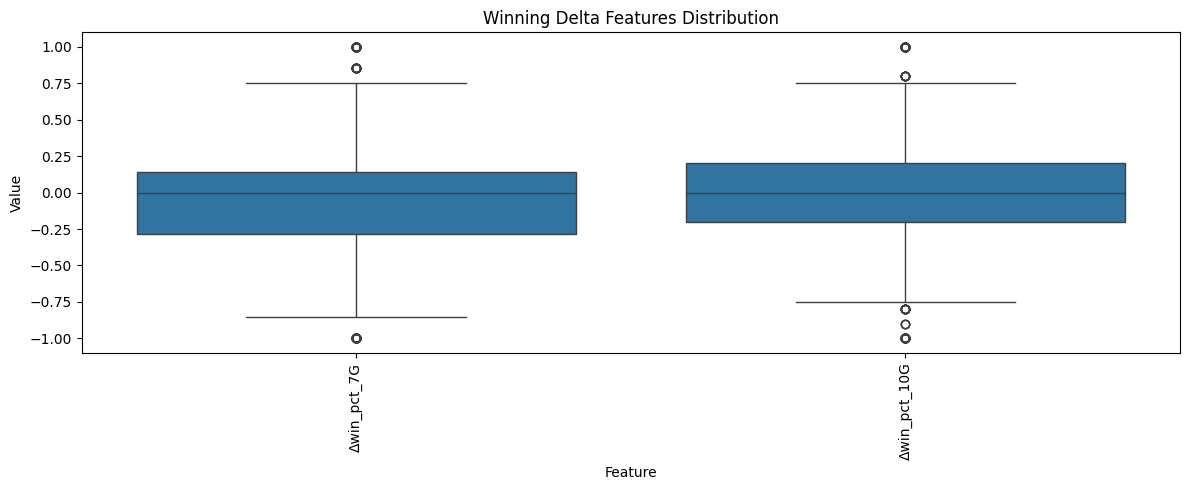

In [38]:
plot_delta_boxplots(game_level_features, like="Δwin", title="Winning Delta Features Distribution")

**Add Analysis**

### Winning Percentage Delta Features by Game Outcome


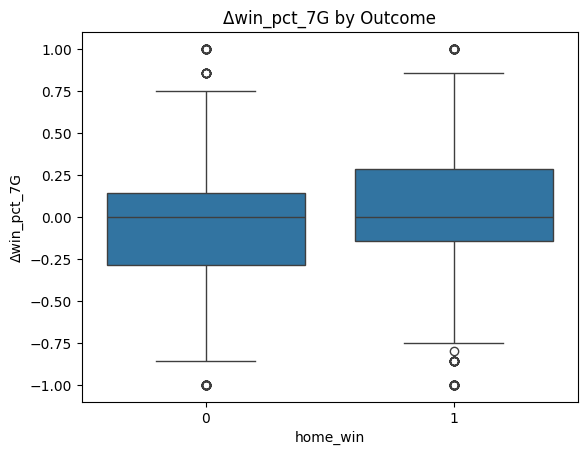

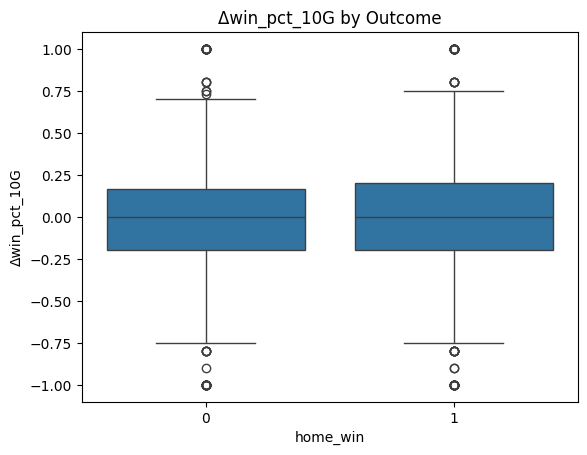

In [39]:
delta_win_pct = game_level_features.filter(like="Δwin")

for col in delta_win_pct.columns:
    plt.figure()
    sns.boxplot(
        data=game_level_features,
        x="home_win",
        y=col
    )
    plt.title(f"{col} by Outcome")
    plt.show()

#### Analysis

The boxplots compare the distribution of the winning percentage delta features (`Δwin_pct_7G` and `Δwin_pct_10G`) across game outcomes. In both cases, the distribution corresponding to games the home team wins appears slightly shifted upward relative to games the home team loses. This suggests that when the home team has a stronger recent winning record relative to the away team, it is somewhat more likely to win the game.

For both rolling windows, the median value for home team wins is modestly higher than for home team losses, indicating a positive relationship between recent relative performance and game outcomes. However, there remains substantial overlap between the two distributions. This overlap indicates that while recent winning percentage differences provide some predictive signal, they are not sufficient on their own to clearly distinguish between wins and losses. This is expected, as baseball outcomes depend on many other factors such as pitching matchups, bullpen performance, offensive production, and game-to-game variability.

The spread of the distributions differs slightly between the two rolling windows. The **7-game window shows somewhat greater variability**, reflecting the higher sensitivity of shorter rolling windows to recent streaks or short-term fluctuations in performance. In contrast, the **10-game window appears slightly more compressed**, suggesting that longer rolling windows smooth out some of this volatility.

Overall, the visualizations indicate that **positive differences in recent winning percentage are somewhat more common in games that the home team wins**, supporting the idea that recent team performance contains useful predictive information. However, the substantial overlap between the distributions reinforces that this feature is best interpreted as one component of a broader set of predictors rather than a dominant standalone signal.

### Winning Correlation

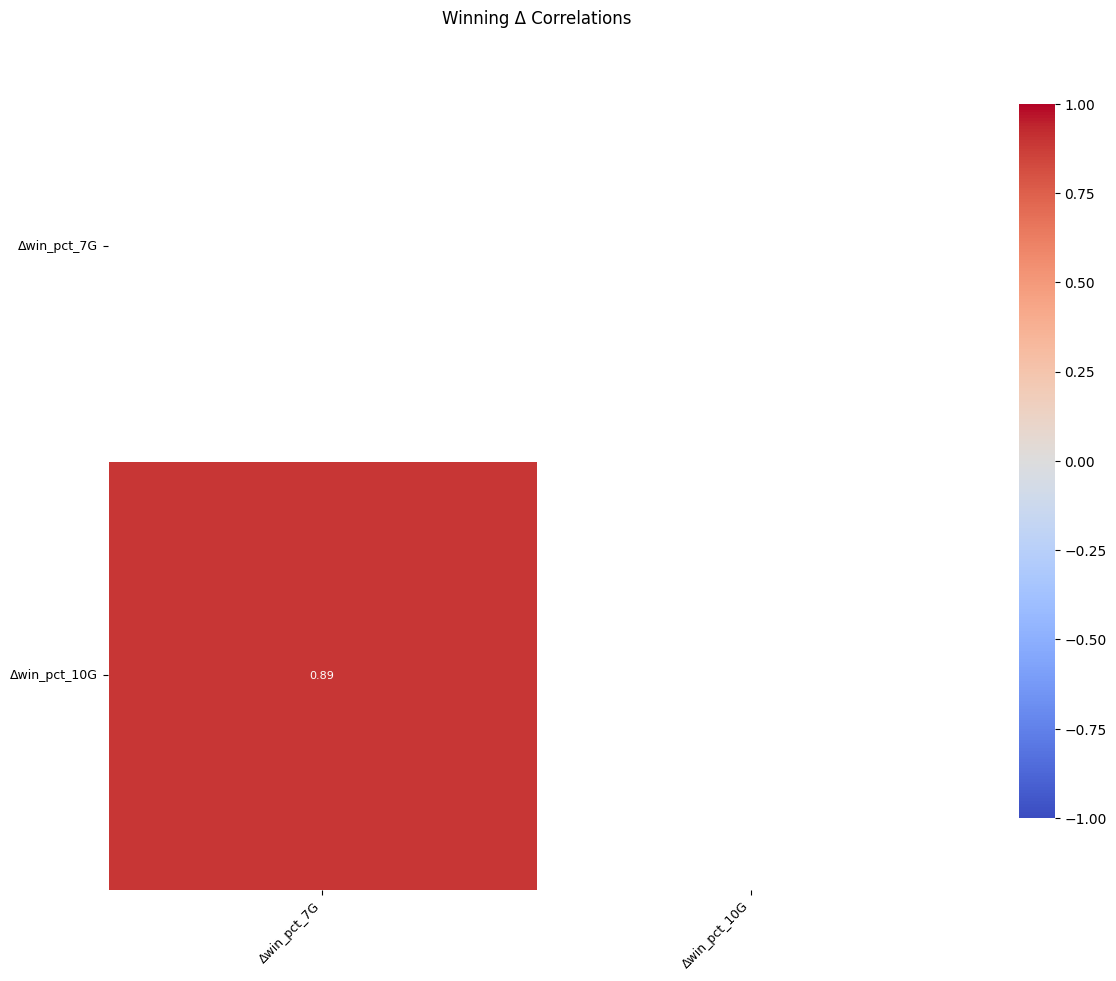

In [41]:
plot_delta_corr_heatmap(game_level_features, group="winning", title="Winning Δ Correlations")

#### TODO: ADD ANALYSIS

## Overall Correlation

Below, I will examine the correlation for all features.

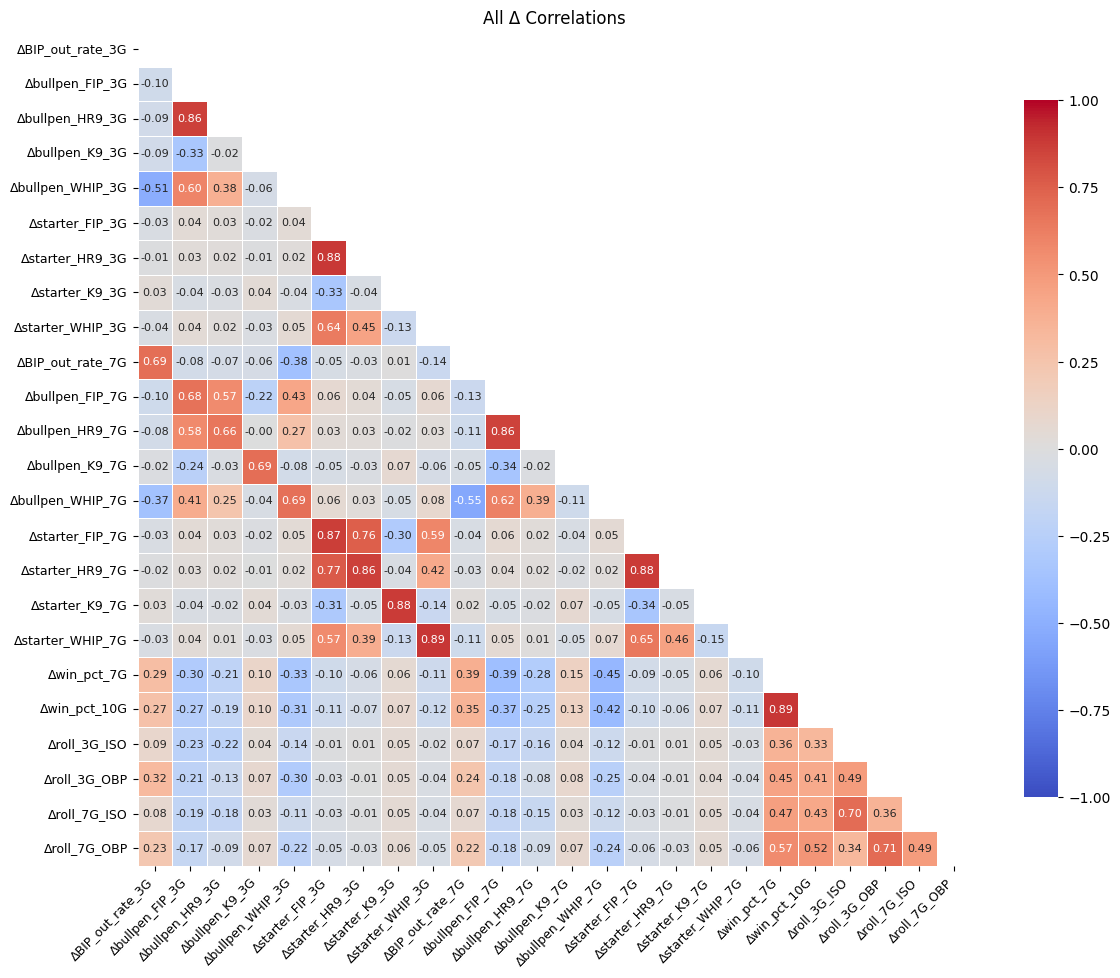

In [40]:
plot_delta_corr_heatmap(game_level_features, group="all", title="All Δ Correlations")

#### Cross-Group Correlations

Across batting, pitching, and fielding features, most correlations are relatively weak, suggesting that these groups capture different aspects of team performance. In general, the **batting metrics show little correlation with pitching or fielding variables**, with most relationships falling below an absolute value of 0.3.

One notable pattern appears between **fielding and bullpen performance**. For example, `ΔBIP_out_rate_3G` and `Δbullpen_WHIP_3G` have a correlation of **−0.51**, while `ΔBIP_out_rate_7G` and `Δbullpen_WHIP_7G` have a correlation of **−0.55**. This negative relationship is intuitive: when a team converts a higher proportion of balls in play into outs, fewer baserunners tend to reach base, which corresponds to lower WHIP values.

Overall, aside from these moderate relationships between fielding and bullpen metrics, **cross-group correlations remain modest**, indicating that batting, pitching, and fielding variables provide largely distinct information about team performance.

## Feature vs Target Correlation

In [43]:
cols_to_drop = [
    "game_id",
    "game_date",
    "home_team",
    "away_team",
    "starter_pitcher_name_home",
    "starter_pitcher_name_away",
    "run_diff",
    "home_win",
    "ballpark"
]

feature_target_corr = (
    game_level_features
    .drop(columns=cols_to_drop)
    .corrwith(game_level_features["home_win"])
    .sort_values()
)

feature_target_corr

Δbullpen_WHIP_7G   -0.064040
Δstarter_WHIP_3G   -0.050684
Δbullpen_FIP_7G    -0.050142
Δstarter_WHIP_7G   -0.045431
Δbullpen_FIP_3G    -0.040391
Δstarter_FIP_7G    -0.038217
Δbullpen_WHIP_3G   -0.037335
Δstarter_FIP_3G    -0.030552
Δbullpen_HR9_3G    -0.021224
Δbullpen_HR9_7G    -0.015058
Δstarter_HR9_7G    -0.010939
Δstarter_HR9_3G    -0.006428
ΔBIP_out_rate_3G    0.018339
Δbullpen_K9_3G      0.023608
Δroll_3G_OBP        0.035070
Δstarter_K9_3G      0.036902
ΔBIP_out_rate_7G    0.037299
Δbullpen_K9_7G      0.037943
Δstarter_K9_7G      0.049941
Δroll_7G_OBP        0.051964
Δroll_3G_ISO        0.056780
Δwin_pct_7G         0.065496
Δroll_7G_ISO        0.068526
Δwin_pct_10G        0.076186
dtype: float64

#### Analysis

# TODO: Update Analysis

The correlations between the matchup delta features and the target variable (`home_win`) are generally small in magnitude, ranging from approximately **−0.06 to 0.07**. This is expected in sports prediction problems, where game outcomes depend on multiple aspects of team performance rather than a single dominant variable. 

The pitching metrics tend to show **negative correlations** with the target variable, particularly for statistics where **lower values indicate better performance**, such as WHIP and FIP. Because the features are defined as the difference between the home and away teams’ metrics, negative values indicate that the home team’s pitchers have been performing better recently. The negative correlations therefore suggest that when the home team has a pitching advantage, especially in **bullpen WHIP and FIP**, the probability of a home win increases.

In contrast, the batting metrics show **positive correlations** with the target. Metrics such as `Δroll_7G_OBP` and `Δroll_7G_ISO` exhibit some of the strongest positive relationships with `home_win`, indicating that when the home team has recently outperformed the opponent offensively, the likelihood of winning increases. Notably, **ISO (a measure of power hitting)** shows the strongest positive correlations among the offensive variables.

Fielding performance, measured by `ΔBIP_out_rate`, shows **smaller positive correlations**, suggesting that defensive advantages may contribute to game outcomes but likely play a more modest role compared to pitching and offensive differences. 

Overall, these results align with typical baseball dynamics: pitching advantages tend to reduce the opponent’s scoring opportunities, while offensive advantages increase the home team’s run-scoring potential.

## Feature Variance Check

Below, I conduct variance check to ensure that the engineered features contain sufficient variability across games. Features with extremely low variance can provide little predictive information and may indicate problems in feature construction.


In [44]:
feature_cols = [c for c in game_level_features.columns if c.startswith("Δ")]

variance_df = (
    game_level_features[feature_cols]
    .var()
    .sort_values()
)

variance_df

Δroll_7G_OBP         0.002563
ΔBIP_out_rate_7G     0.003130
Δroll_7G_ISO         0.004017
Δroll_3G_OBP         0.005171
ΔBIP_out_rate_3G     0.006604
Δroll_3G_ISO         0.008263
Δwin_pct_10G         0.080803
Δwin_pct_7G          0.106915
Δbullpen_WHIP_7G     0.215768
Δstarter_WHIP_7G     0.440332
Δbullpen_WHIP_3G     0.463566
Δstarter_WHIP_3G     0.560097
Δbullpen_HR9_7G      0.936064
Δstarter_HR9_7G      1.834379
Δbullpen_HR9_3G      2.105375
Δstarter_HR9_3G      2.514672
Δbullpen_FIP_7G      3.022146
Δstarter_FIP_7G      5.848817
Δbullpen_K9_7G       6.385618
Δbullpen_FIP_3G      6.549272
Δstarter_FIP_3G      7.797487
Δstarter_K9_7G      10.453480
Δbullpen_K9_3G      13.074754
Δstarter_K9_3G      13.760798
dtype: float64

### Feature Variance Check

The results show that all delta features exhibit meaningful variation. The smallest variances occur for the batting metrics (`Δroll_OBP` and `Δroll_ISO`) and the fielding metric (`ΔBIP_out_rate`). These lower values are expected because these statistics are naturally bounded within relatively small ranges. In contrast, pitching metrics such as `K9`, `HR9`, and `FIP` show substantially larger variance, reflecting both the wider range of possible differences in pitching performance between teams and the presence of some extreme values.

Overall, no features exhibit near-zero variance, suggesting that all engineered variables contain useful variability and are appropriate for inclusion in the modeling stage.